# $\beta$ $\beta$ offline signal reconstruction

In [1]:
# S2 signal script
import sys
sys.path.append('/home/investigator/mariandbt/python/notebooks/modules')

from import_modules import *

import s2_simulation as s2sim
from s2_simulation import unit

In [2]:
path = '/home/investigator/mariandbt/python/data'
path = path + '/20240313_s2simulation'

In [3]:
sns_path = os.path.join(path, "ie/20240405_Next100_ie_s2_1.next.h5")
s2_table_path = os.path.join(path, "s2tab/20240405_s2_table.h5")
event_path = os.path.join(path, "bb/20240228_Next100_10ev_ELon_bb_1.next.h5") # 10 full bb w s2


In [4]:
event, sensor = 0, 202

In [5]:
# Create TPC
TPC     = s2sim.HPGXeTPC()
TPC.SetDefaults(sns_path)

Default parameters set succesfully :) TPC ready to use


/home/investigator/miniconda3/envs/IC-3.8-2022-04-13/lib/python3.8/site-packages/pandas/io/pytables.py:3523: IncompatibilityWarning: 
where criteria is being ignored as this version [0.0.0] is too old (or
not-defined), read the file in and write it out to a new file to upgrade (with
the copy_to method)

  warnings.warn(ws, IncompatibilityWarning)


In [6]:
nexusEvent = s2sim.nexusEvent(event_path, event)
nexusEvent.AddDriftAndDiffusion(TPC)

In [7]:
s2table = s2sim.s2Table(s2_table_path)

In [8]:
# %%timeit # (~4mins) (~25s no sé why...)
s2_signal = s2sim.s2Signal(s2table, TPC, nexusEvent)

In [ ]:
# %%timeit # (~4mins/sensor for t_bin = 0.1ns; 35.1s in total for t_bin = 1ns)
s2_signal.AddShapinAndSamplin(samplin_rate = 25*unit.ns, t_binin = 1*unit.ns)

In [ ]:
t, waveform, ax = s2_signal.PrintWaveform(sensor, shaped_and_sampled = False)
ax.legend();
waveform.sum()

In [ ]:
t, waveform, ax = s2_signal.PrintWaveform(sensor, shaped_and_sampled = True, units = 'pes/ns')
ax.legend()
np.trapz(y = waveform, x = t.to(unit.ns).magnitude)

In [ ]:
t, waveform, ax = s2_signal.PrintWaveform(sensor, shaped_and_sampled = True, units ='mA')
ax.legend()


In [ ]:
t, waveform, ax = s2_signal.PrintWaveform(sensor, shaped_and_sampled = True, units = 'mV')
ax.legend()


# $\beta$ $\beta$ offline dynamic range

In [1]:
# S2 signal script
import sys
sys.path.append('/home/investigator/mariandbt/python/notebooks/modules')

from import_modules import *

import s2_simulation as s2sim
from s2_simulation import unit

In [2]:
path = '/home/investigator/mariandbt/python/data'
path = path + '/20240313_s2simulation'

In [3]:
sns_path = os.path.join(path, "ie/20240405_Next100_ie_s2_1.next.h5")
s2_table_path = os.path.join(path, "s2tab/20240405_s2_table.h5")
event_path = os.path.join(path, "bb/20240228_Next100_10ev_ELon_bb_1.next.h5") # 10 full bb w s2
event_path2 = os.path.join(path, "bb/20240306_Next100_200ev_ELoff_bb_1.next.h5") # 200 evs w/o s2


In [4]:
# Create TPC
TPC     = s2sim.HPGXeTPC()
TPC.SetDefaults(sns_path)

Default parameters set succesfully :) TPC ready to use


/home/investigator/miniconda3/envs/IC-3.8-2022-04-13/lib/python3.8/site-packages/pandas/io/pytables.py:3523: IncompatibilityWarning: 
where criteria is being ignored as this version [0.0.0] is too old (or
not-defined), read the file in and write it out to a new file to upgrade (with
the copy_to method)

  warnings.warn(ws, IncompatibilityWarning)


In [5]:
s2table = s2sim.s2Table(s2_table_path)

In [6]:
list_of_bb = [event_path, event_path2]
# list_of_bb = [event_path2]


In [7]:
# %%timeit # (37.1s /event)
dyn_range, dyn_range_units = s2sim.DynamicRange(s2table, 
                                                TPC, 
                                                list_of_bb,
                                                shapin_tau = 155 *unit.ns,
                                                samplin_rate = 25*unit.ns,
                                                t_binin = 10*unit.ns,
                                                units = 'mV'
                                               )

Dynamic range (Processing event 1/10 in file 1/2...)                                                                                                        
Dynamic range (Processing event 2/10 in file 1/2...)                                                                                                        
Dynamic range (Processing event 3/10 in file 1/2...)                                                                                                        
Dynamic range (Processing event 4/10 in file 1/2...)                                                                                                        
Dynamic range (Processing event 5/10 in file 1/2...)                                                                                                        
Dynamic range (Processing event 6/10 in file 1/2...)                                                                                                        
Dynamic range (Processing event 7/10 in file 1/2...)      

/home/investigator/mariandbt/python/notebooks/modules/s2_simulation.py:327: RuntimeWarning: overflow encountered in multiply
  signal = (rise_term * decay_term)


Dynamic range (Processing event 8/10 in file 1/2...)                                                                                                        
Dynamic range (Processing event 9/10 in file 1/2...)                                                                                                        
Dynamic range (Processing event 10/10 in file 1/2...)                                                                                                          
Dynamic range (Processing event 1/200 in file 2/2...)                                                                                                          
Dynamic range (Processing event 2/200 in file 2/2...)                                                                                                          
Dynamic range (Processing event 3/200 in file 2/2...)                                                                                                          


/home/investigator/mariandbt/python/notebooks/modules/s2_simulation.py:324: RuntimeWarning: overflow encountered in exp
  rise_term = 1 - np.exp(-(t - t0) / (tau * rise_time))
/home/investigator/mariandbt/python/notebooks/modules/s2_simulation.py:325: RuntimeWarning: overflow encountered in exp
  decay_term = np.exp(-(t - t0) / tau)


Dynamic range (Processing event 4/200 in file 2/2...)                                                                                                          
Dynamic range (Processing event 5/200 in file 2/2...)                                                                                                          
Dynamic range (Processing event 6/200 in file 2/2...)                                                                                                          
Dynamic range (Processing event 7/200 in file 2/2...)                                                                                                          
Dynamic range (Processing event 8/200 in file 2/2...)                                                                                                          
Dynamic range (Processing event 9/200 in file 2/2...)                                                                                                          
Dynamic range (Processing event 10/200 i

Dynamic range (Processing event 54/200 in file 2/2...)                                                                                                            
Dynamic range (Processing event 55/200 in file 2/2...)                                                                                                            
Dynamic range (Processing event 56/200 in file 2/2...)                                                                                                            
Dynamic range (Processing event 57/200 in file 2/2...)                                                                                                            
Dynamic range (Processing event 58/200 in file 2/2...)                                                                                                            
This is an empty event :(
Dynamic range (Processing event 59/200 in file 2/2...)                                                                                                         

Dynamic range (Processing event 103/200 in file 2/2...)                                                                                                              
Dynamic range (Processing event 104/200 in file 2/2...)                                                                                                              
Dynamic range (Processing event 105/200 in file 2/2...)                                                                                                              
Dynamic range (Processing event 106/200 in file 2/2...)                                                                                                              
Dynamic range (Processing event 107/200 in file 2/2...)                                                                                                              
Dynamic range (Processing event 108/200 in file 2/2...)                                                                                                              
Dyna

Dynamic range (Processing event 152/200 in file 2/2...)                                                                                                              
Dynamic range (Processing event 153/200 in file 2/2...)                                                                                                              
Dynamic range (Processing event 154/200 in file 2/2...)                                                                                                              
Dynamic range (Processing event 155/200 in file 2/2...)                                                                                                              
Dynamic range (Processing event 156/200 in file 2/2...)                                                                                                              
This is an empty event :(
Dynamic range (Processing event 157/200 in file 2/2...)                                                                                         

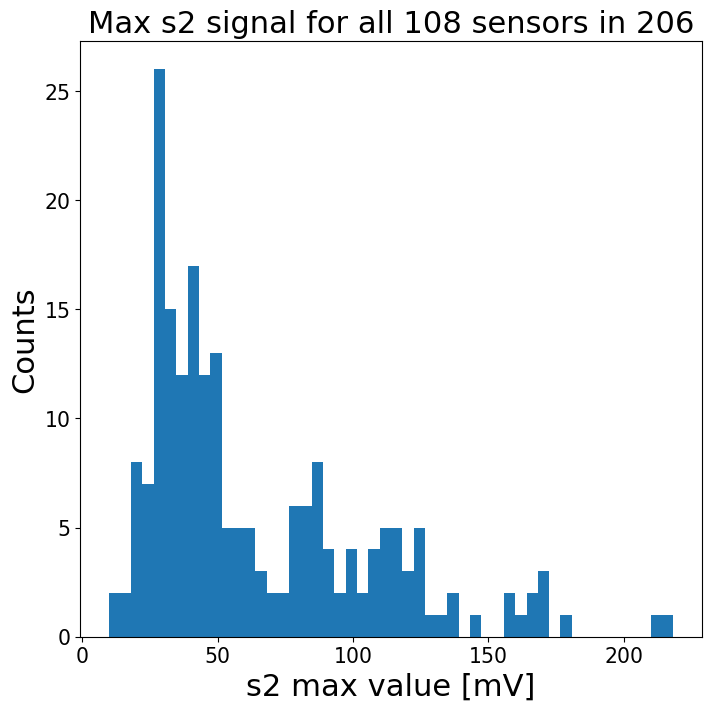

In [20]:
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize=(7, 7), constrained_layout=True) # Create a new figure

font_size   = 22

magnitudes = [value.magnitude for value in dyn_range.values()]
_ = ax.hist(dyn_range, bins = 50)

ax.set_title(f'Max s2 signal for all {TPC.NSensors} sensors in {len(dyn_range.keys())} events', fontsize = font_size);
ax.set_xlabel(f's2 max value [{dyn_range_units:~}]', fontsize = font_size);
ax.set_ylabel('Counts', fontsize = font_size);

ax.tick_params(axis='both', labelsize = font_size*2/3);